<h1 style="color: RGB(27, 169, 127); font-size: 50pt";>PAP 2.2 – Python-Auswertung</h1>

## Wichtige Funktionen für das PAP.

Alle in diesem Dokument geschriebenen Zeilen Code sind von mir eigenständig geschrieben. Für ein sauberes und struktiriertes Dokument wurde eine eigene Pythonlibary geschrieben, welche insbesondere ans PAP angepasst wurde. Dieses ist unter dem Namen "Papulator" auf meinem GitHub zu finden. Diese soll setig ausgearbeitet werden. Der Stand dieses Protokolls ist der 29.04.2026.
 
----

# Inhaltsverzeichnis zur Auswertung
* [Definition der Versuchsvariablen](#Definition-der-Versuchsvariablen)
* [Import aller genutzen Libaries](#Import-aller-genutzen-Libaries)
* [Auswertung der Aufgaben](#Auswertung-der-Aufgaben)
    * [Aufgabe 1](#Aufgabe-1)
    * [Aufgabe 2](#Aufgabe-2)
    * [Aufgabe 3](#Aufgabe-3)
    * [Aufgabe 4](#Aufgabe-4)

---
---

# Definition der Versuchsvariablen

Im Folgenden sind Versuchsvariablen definiert, die für einen besseren Workflow sorgen sollen. Diese werden zum exportieren und überschreiben von Dateien wichtig sein und ermöglichen es, diese Datei für jeden Versuch zu benutzen und lediglich die Variablen zu verändern. Es ist jedoch empfohlen eine Kopie der Forlage für jeden Versuch zu machen, damit dieses Dokument strukturiert bleibt.

Zudem sind wichtige Konstanten definiert, die immer wieder auftauchen.

In [44]:
experiment_number = "255"
experiment_name = "Versuchs_Name" 
task = "0z"
plt_save_folder = f"../img/plots/"

# Import aller genutzen Libaries

In [45]:
# Eigene Pythonlibary für das Pap
import Papulator as pap
from Papulator import Colors as c
from Papulator import const
from Papulator import Sympy_Symbols as sym

# Numpy für bessere Berechnungen
import numpy as np
from numpy import exp, sqrt, log, pi
from uncertainties import unumpy as unp

# Weiteres für bessere Rechnungen
import pylab as py

import math

# Berechnungen und Plotting
from scipy import odr
import scipy.optimize
from scipy.optimize import curve_fit
from scipy.stats import norm
from scipy.stats import chi2
from scipy.stats import poisson
from scipy.signal import find_peaks
from scipy.signal import argrelextrema, argrelmin, argrelmax
from scipy.special import factorial
from scipy.integrate import quad

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib.transforms as transforms

import astropy.units as u

# Zum Auslesen von Dateien und ähnlichem
import os
import os.path

import pandas as pd
import csv
import re

from io import StringIO

# Besseres Funktionen handling
import sympy as sp
from sympy import separatevars

<hr>
<hr>

# Auswertung der Aufgaben

<hr>

## Aufgabe 1

In [46]:
# Import txt Data
angle_T1, counts_T1 = np.loadtxt('data/T1.txt', dtype=str, unpack=True)
angle_T1 = np.char.replace(angle_T1, ',', '.').astype(float)
err_angle_T1 = 0.05 # deg
counts_T1 = np.char.replace(counts_T1, ',', '.').astype(float)
err_counts_T1 = sqrt(counts_T1)

In [47]:
# linear regression
def linear(x,m,b):
    return m * x + b

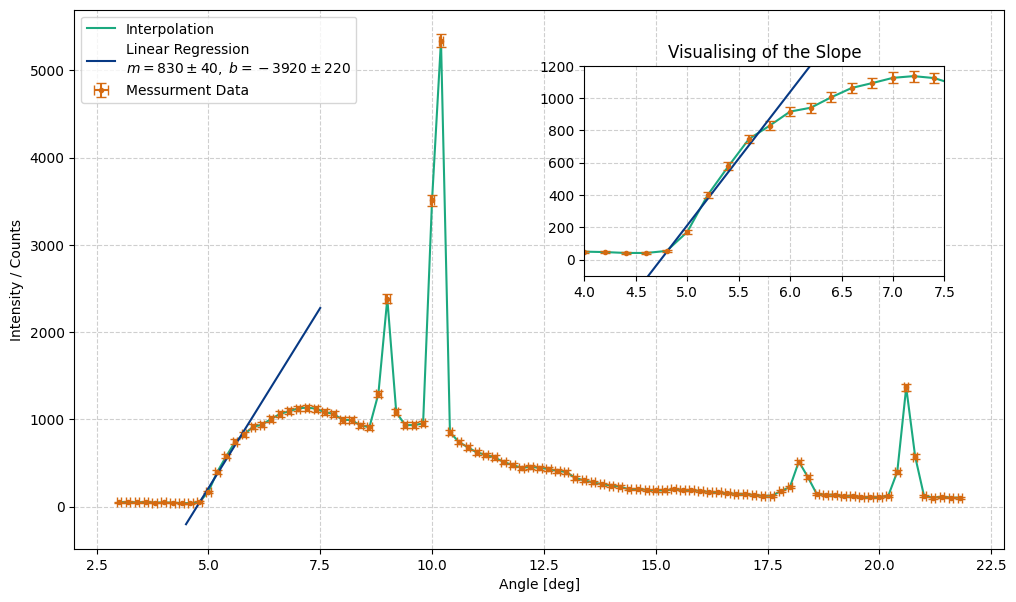

The underground is 53.6 couts


In [48]:
task = '1a'
plt.figure(figsize = (12,7))

# Default interpolation
plt.plot(
    angle_T1,
    counts_T1,
    label='Interpolation',
    )

# Messurment data
plt.errorbar(
    angle_T1,
    counts_T1,
    err_counts_T1,
    err_angle_T1,
    label='Messurment Data',
    marker = '.',
    ls = ' ',
    capsize=3.5
    )

# Regression
# Range of linear regression
start, end = 9, 15
popt, pcov = curve_fit(linear, angle_T1[start:end], counts_T1[start:end], sigma=err_counts_T1[start:end])

slope_T1 = popt[0]
ordinate_T1 = popt[1]

# Extract uncertainties
perr = np.sqrt(np.diag(pcov)) 

err_slope_T1 = perr[0]
err_ordinate_T1 = perr[1]

x = np.linspace(4.5, 7.5, 100)
plt.plot(
    x,
    linear(x, *popt),
    label = f'Linear Regression\n$m={pap.round_sig_digs(err_slope_T1, slope_T1)[2]}, \\; b={pap.round_sig_digs(err_ordinate_T1, ordinate_T1)[2]}$'
)

plt.legend(loc = 'upper left')
plt.xlabel('Angle [deg]')
plt.ylabel('Intensity / Counts')
plt.grid(alpha = 0.6)
# Small Window
a = plt.axes([.55, .50, .3, .3], facecolor = 'white')

plt.plot(
    angle_T1,
    counts_T1,
    label='Interpolation',
    )

# Messurment data
plt.errorbar(
    angle_T1,
    counts_T1,
    err_counts_T1,
    label='Messurment Data',
    marker = '.',
    ls = ' ',
    capsize=3.5
    )

plt.plot(
    x,
    linear(x, *popt),
    label = f'Linear Regression\n$m={popt[0]:.2f}, \\; b={popt[1]:.2f}$'
)

plt.xlim(4, 7.5)
plt.ylim(-100, 1200)
plt.title('Visualising of the Slope')
plt.grid(alpha = 0.6)

plt.savefig(f'{plt_save_folder}hohle_spectrum_and_slope_{task}.pdf')
plt.show()

underground = counts_T1[start]
err_underground = sqrt(underground)
print(f'The underground is {underground} couts')

In [49]:
# For better structure, here are the params of the slope printed out:
print(f'Corsssection with the Ordinate: b = {pap.round_sig_digs(err_ordinate_T1, ordinate_T1)[2]}')
print(f'Slope: m = {pap.round_sig_digs(err_slope_T1, slope_T1)[2]}')

m_T1_rnd = pap.round_sig_digs(err_slope_T1, slope_T1)[0]
err_m_T1_rnd = pap.round_sig_digs(err_slope_T1, slope_T1)[1]

b_T1_rnd = pap.round_sig_digs(err_ordinate_T1, ordinate_T1)[0]
err_b_T1_rnd = pap.round_sig_digs(err_ordinate_T1, ordinate_T1)[1]

Corsssection with the Ordinate: b = -3920 \pm 220
Slope: m = 830 \pm 40


In [50]:
# Formula for calucation the critical angle
crit_angle = - sym.b / sym.m

values = np.array([
    b_T1_rnd, err_b_T1_rnd,
    m_T1_rnd, err_m_T1_rnd,
])

temp = pap.do_it(crit_angle, [sym.b, sym.m], values, print_formula=True)
val = temp[:,0][0]
err = temp[:,1][0]
rounded = pap.round_sig_digs(err,val)

val_crit_angle = rounded[0]
err_crit_angle = rounded[1]

print(f'The critical angle is: ({rounded[2]})°')

gegebene Funktion:


<IPython.core.display.Math object>

-----------------------
Formel des absoluten Fehlers:


<IPython.core.display.Math object>

-----------------------
Formel des relativen Fehlers:


<IPython.core.display.Math object>

-----------------------
The critical angle is: (4.7 \pm 0.3)°


In [51]:
# Next the critical wavelength is being calucated

# constants in use
d_LiF = 201.4 #* 1e-12 #piko to just meter

# converting angel:
val_crit_angle_rad = float(val_crit_angle) * np.pi / 180
err_crit_angle_rad = float(err_crit_angle) * np.pi / 180


#Formula for the critical wavelength
crit_wave = 2 * sym.d * sp.sin(sym.x)  / sym.n

# values to set into the formula:
values = np.array([
    val_crit_angle_rad, err_crit_angle_rad,
    d_LiF,
    1
])

temp = pap.do_it(crit_wave, [sym.x, sym.d, sym.n], values, [sym.d, sym.n], print_formula=True)

val = temp[:,0][0] 
err = temp[:,1][0]
rounded = pap.round_sig_digs(err,val)

val_crit_wave = (rounded[0])
err_crit_wave = (rounded[1])

print(f'The critical wavelength is: ({rounded[2]}) pm')

gegebene Funktion:


<IPython.core.display.Math object>

-----------------------
Formel des absoluten Fehlers:


<IPython.core.display.Math object>

-----------------------
Formel des relativen Fehlers:


<IPython.core.display.Math object>

-----------------------
The critical wavelength is: (33.0 \pm 2.1) pm


In [52]:
# Calculation planks kosntant

crit_lambda_sym = sp.symbols(r'\lambda_\text{{crit}}')

# Formula
planks_T1 = crit_lambda_sym * sym.e * sym.U / sym.c

# constans/values
U_B = 35 * 1e3  # V
err_U_B = 0.05 * 1e3 # V

lams = float(val_crit_wave) * 1e-12
err_lams = float(err_crit_wave) * 1e-12

values = np.array([
    lams, err_lams,
    U_B, err_U_B,
    const.c,
    const.e
])

temp = pap.do_it(planks_T1, [crit_lambda_sym, sym.U, sym.c, sym.e], values, [sym.c, sym.e], True)

# For plank we expect dimension of 10⁻34
val = temp[:,0][0] * 1e34
err = temp[:,1][0] * 1e34

rounded = pap.round_sig_digs(err,val)

val_h_T1 = rounded[0]
err_h_T1 = rounded[1]

print(f'The planks constant is is: ({rounded[2]}) * 1e-34 J \\ s')

print(f'Its standard diviation to the lit value is: {pap.std_abw(float(val_h_T1), const.h * 1e34, float(err_h_T1))} sigma')

gegebene Funktion:


<IPython.core.display.Math object>

-----------------------
Formel des absoluten Fehlers:


<IPython.core.display.Math object>

-----------------------
Formel des relativen Fehlers:


<IPython.core.display.Math object>

-----------------------
The planks constant is is: (6.2 \pm 0.4) * 1e-34 J \ s
Its standard diviation to the lit value is: 1.07 sigma


In [53]:
#Formula for the critical wavelength
crit_wave = 2 * sym.d * sp.sin(sym.x)  / sym.n

# values to set into the formula:
values = np.array([
    val_crit_angle_rad, err_crit_angle_rad,
    d_LiF,
    2
])

temp = pap.do_it(crit_wave, [sym.x, sym.d, sym.n], values, [sym.d, sym.n], print_formula=True)

val = temp[:,0][0] 
err = temp[:,1][0]
rounded = pap.round_sig_digs(err,val)

val_crit_wave_2Ord = float(rounded[0])
err_crit_wave_2Ord = float(rounded[1])

print(f'The critical wavelength for the second order is: ({rounded[2]}) pm')

gegebene Funktion:


<IPython.core.display.Math object>

-----------------------
Formel des absoluten Fehlers:


<IPython.core.display.Math object>

-----------------------
Formel des relativen Fehlers:


<IPython.core.display.Math object>

-----------------------
The critical wavelength for the second order is: (16.5 \pm 1.1) pm


In [54]:
# Expected angle of the second peak

d_LiF = 201.4 #* 1e-12 #piko to just meter
second_peak_angle = sp.asin(((2 * crit_lambda_sym / (2*  sym.d)))) / (sp.pi / 180)
 
values = np.array([
    val_crit_wave, err_crit_wave,
    d_LiF
])

temp = pap.do_it(second_peak_angle, [crit_lambda_sym, sym.d], values, [sym.d], True)

val = temp[:,0][0]
err = temp[:,1][0]

rounded = pap.round_sig_digs(err,val)

val_second_angle = rounded[0]
err_second_angle = rounded[1]

print(f'The next peak starts as angle of: ({rounded[2]})°')

gegebene Funktion:


<IPython.core.display.Math object>

-----------------------
Formel des absoluten Fehlers:


<IPython.core.display.Math object>

-----------------------
Formel des relativen Fehlers:


<IPython.core.display.Math object>

-----------------------
The next peak starts as angle of: (9.4 \pm 0.6)°


<hr>

## Aufgabe 2

### First Order

In [55]:
# Import txt Data
angle_1ord, counts_1ord = np.loadtxt('data/T2_1O.txt', dtype=str, unpack=True)
angle_1ord = np.char.replace(angle_1ord, ',', '.').astype(float)
err_angle_1ord = 0.05 # deg
counts_1ord = np.char.replace(counts_1ord, ',', '.').astype(float)
err_counts_1ord = sqrt(counts_1ord)

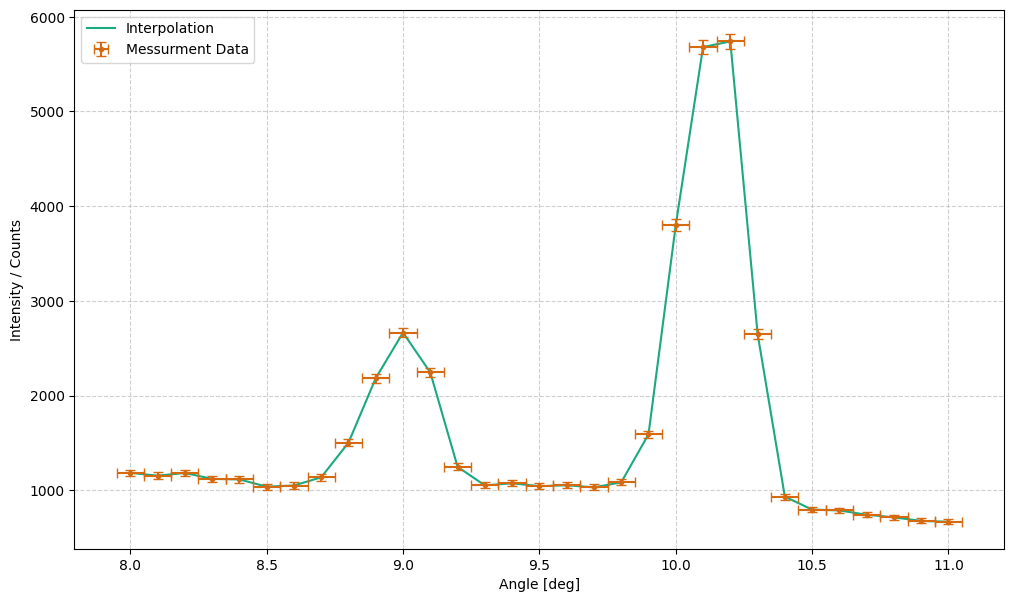

In [56]:
task = '2a'
plt.figure(figsize = (12,7))

# Default interpolation
plt.plot(
    angle_1ord,
    counts_1ord,
    label='Interpolation',
    )

# Messurment data
plt.errorbar(
    angle_1ord,
    counts_1ord,
    err_counts_1ord,
    err_angle_1ord,
    label='Messurment Data',
    marker = '.',
    ls = ' ',
    capsize=3.5
    )

plt.legend(loc = 'upper left')
plt.xlabel('Angle [deg]')
plt.ylabel('Intensity / Counts')
plt.grid(alpha = 0.6)

plt.savefig(f'{plt_save_folder}first_order_LiF_{task}.pdf')
plt.show()

In [57]:
# find extrima
peaks, _ = find_peaks(counts_1ord, height=2500)
n_max_alpha = counts_1ord[peaks[1]]
deg_max_alpha = angle_1ord[peaks[1]]
n_max_beta = counts_1ord[peaks[0]]
deg_max_beta = angle_1ord[peaks[0]]

In [58]:
# function
wavlength_by_ord  = 2 / sym.n * sym.d * sp.sin(sym.x)

degs = np.array([deg_max_alpha, deg_max_beta])
print(degs)
values = np.column_stack([
    degs * np.pi / 180, [0.05 * np.pi / 180] * 2,
    [1] * 2,
    [d_LiF] * 2
])

temp = pap.do_it(wavlength_by_ord, [sym.x, sym.n, sym.d], values, [sym.n, sym.d], True)
# print(temp)
# print(temp[:,0])

vals = temp[:,0]
err = temp[:,1]

alpha_1 = vals[0]
err_alpha_1 = err[0]

beta_1 = vals[1]
err_beta_1 = err[1]

print(f'Wavelength of alpha order 1: {pap.round_sig_digs(err_alpha_1, alpha_1)[2]}')
print(f'Wavelength of beta order 1: {pap.round_sig_digs(err_beta_1, beta_1)[2]}')


[10.2  9. ]
gegebene Funktion:


<IPython.core.display.Math object>

-----------------------
Formel des absoluten Fehlers:


<IPython.core.display.Math object>

-----------------------
Formel des relativen Fehlers:


<IPython.core.display.Math object>

-----------------------
Wavelength of alpha order 1: 71.3 \pm 0.3
Wavelength of beta order 1: 63.0 \pm 0.3


### Second Order

In [59]:
# Import txt Data
angle_2ord, counts_2ord = np.loadtxt('data/T2_2O.txt', dtype=str, unpack=True)
angle_2ord = np.char.replace(angle_2ord, ',', '.').astype(float)
err_angle_2ord = 0.05 # deg
counts_2ord = np.char.replace(counts_2ord, ',', '.').astype(float)
err_counts_2ord = sqrt(counts_2ord)

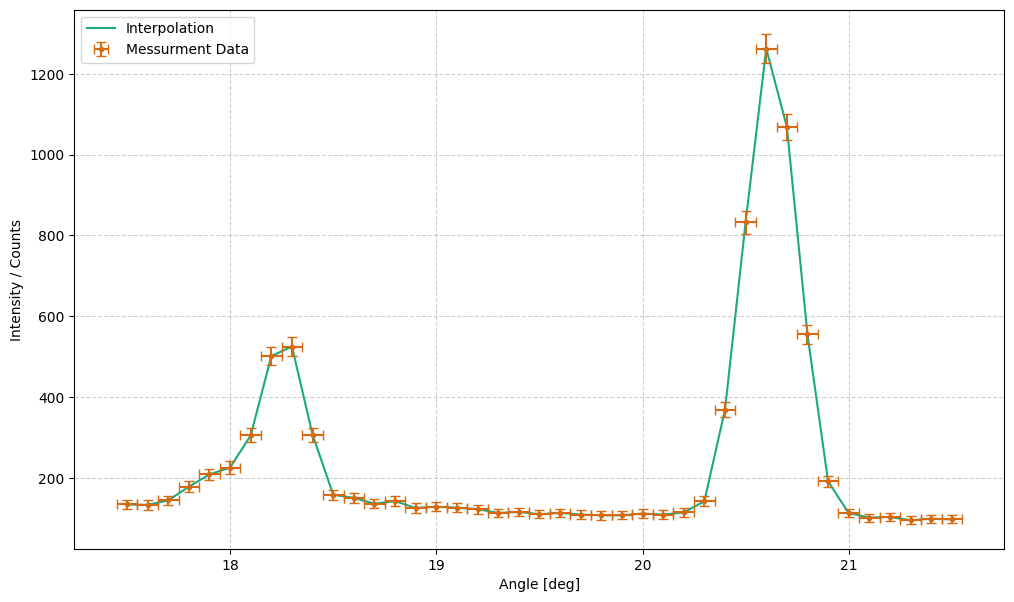

In [60]:
task = '2b'
plt.figure(figsize = (12,7))

# Default interpolation
plt.plot(
    angle_2ord,
    counts_2ord,
    label='Interpolation',
    )

# Messurment data
plt.errorbar(
    angle_2ord,
    counts_2ord,
    err_counts_2ord,
    err_angle_2ord,
    label='Messurment Data',
    marker = '.',
    ls = ' ',
    capsize=3.5
    )

plt.legend(loc = 'upper left')
plt.xlabel('Angle [deg]')
plt.ylabel('Intensity / Counts')
plt.grid(alpha = 0.6)

plt.savefig(f'{plt_save_folder}second_order_LiF_{task}.pdf')
plt.show()

In [61]:
# find extrima
peaks_2, _ = find_peaks(counts_2ord, height=400)
n_max_alpha_2 = counts_2ord[peaks_2]
deg_max_alpha_2 = angle_2ord[peaks_2[1]]
n_max_beta_2 = counts_2ord[peaks_2[0]]
deg_max_beta_2 = angle_2ord[peaks_2[0]]

print(deg_max_alpha_2, deg_max_beta_2)

20.6 18.3


In [62]:
# function
wavlength_by_ord  = 2 / sym.n * sym.d * sp.sin(sym.x)

degs = np.array([deg_max_alpha_2, deg_max_beta_2])
print(degs)

values = np.column_stack([
    degs * np.pi / 180, [0.05 * np.pi / 180] * 2,
    [2] * 2,
    [d_LiF] * 2
])

temp = pap.do_it(wavlength_by_ord, [sym.x, sym.n, sym.d], values, [sym.n, sym.d], True)
# print(temp)
# print(temp[:,0])

vals = temp[:,0]
err = temp[:,1]

alpha_2 = vals[0]
err_alpha_2 = err[0]

beta_2 = vals[1]
err_beta_2 = err[1]

print(f'Wavelength of alpha order 2: ({pap.round_sig_digs(err_alpha_2, alpha_2)[2]}) pm')
print(f'Wavelength of beta order 2: ({pap.round_sig_digs(err_beta_2, beta_2)[2]} pm)')


[20.6 18.3]
gegebene Funktion:


<IPython.core.display.Math object>

-----------------------
Formel des absoluten Fehlers:


<IPython.core.display.Math object>

-----------------------
Formel des relativen Fehlers:


<IPython.core.display.Math object>

-----------------------
Wavelength of alpha order 2: (70.86 \pm 0.16) pm
Wavelength of beta order 2: (63.24 \pm 0.17 pm)


In [63]:
# averaging:
Mo_wavelength_alpha = (alpha_2 + alpha_1) / 2
err_Mo_wavelength_alpha = sqrt(err_alpha_2**2 + err_alpha_1**2)

Mo_wavelength_beta = (beta_2 + beta_1) / 2
err_Mo_wavelength_beta = sqrt(err_beta_2**2 + err_beta_1**2)

print(f'The wavelength of Mo for alpha is: ({pap.round_sig_digs(err_Mo_wavelength_alpha ,Mo_wavelength_alpha)[2]}) pm')
print(f'The wavelength of Mo for beta is: ({pap.round_sig_digs(err_Mo_wavelength_beta ,Mo_wavelength_beta)[2]}) pm')

The wavelength of Mo for alpha is: (71.1 \pm 0.4) pm
The wavelength of Mo for beta is: (63.1 \pm 0.4) pm


In [64]:
Mo_Kalpha_lit = 71.1 # pm
Mo_Kbeta_lit = 63.1 # pm

sig_diveration_alpha = pap.std_abw(Mo_Kalpha_lit, Mo_wavelength_alpha, err_Mo_wavelength_alpha)
sig_diveration_beta = pap.std_abw(Mo_Kbeta_lit, Mo_wavelength_beta, err_Mo_wavelength_beta)

print(f'The standard diviation from the litature value of the K Alpha line:\n{sig_diveration_alpha}')
print(f'The standard diviation from the litature value of the K Beta line:\n{sig_diveration_beta}')
print('Those are only true for the non rounded values!')

The standard diviation from the litature value of the K Alpha line:
0.01
The standard diviation from the litature value of the K Beta line:
0.06
Those are only true for the non rounded values!


In [65]:
def gauss(x, A, mu, sig):
    return A / (sqrt(2 * pi) * sig) * exp(- (x - mu) ** 2 / (2 * sig ** 2)) + 800

Fitted parameters (Amplitude, Mean, Sigma): [1.57660646e+03 1.01289766e+01 1.15310484e-01]
Errors (Standard Deviations): [8.30446611e+01 6.80407916e-03 5.75718969e-03]


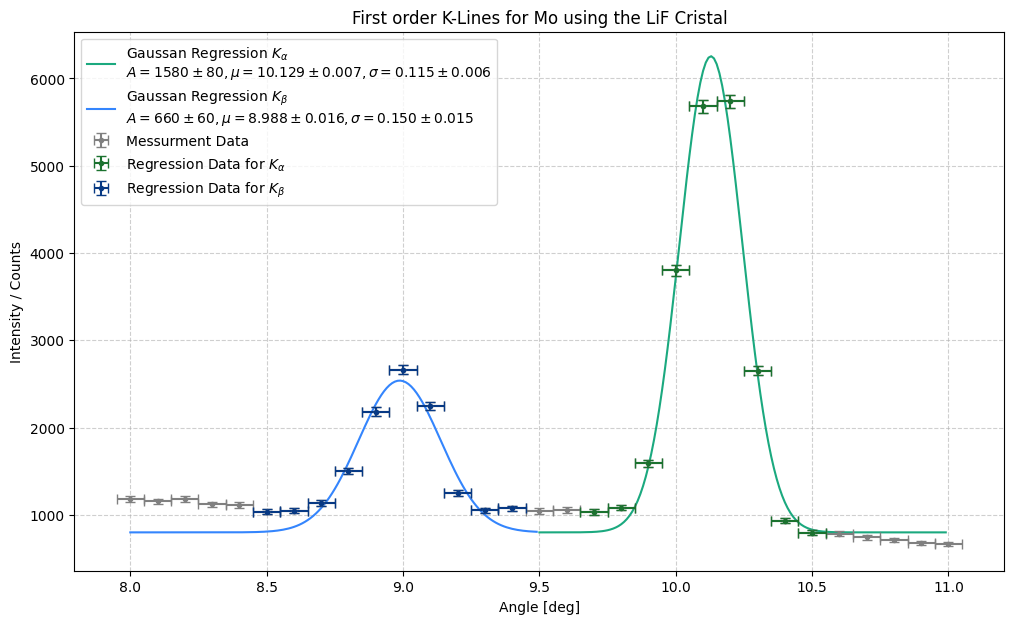

In [66]:
# Finding the HWFM of the K alpha line in first order
task = '2c'
plt.figure(figsize = (12,7))

# Regressionfor K Alpha
a_start, a_end = 17, -5

p0_alpha = [5000, 10, 0.4]
popt_alpha, pcov_alpha = curve_fit(gauss, angle_1ord[a_start:a_end], counts_1ord[a_start:a_end], p0_alpha, sigma = err_counts_1ord[a_start:a_end])
degx_alpha = np.arange(9.5,11, 0.01)

perr_alpha = np.sqrt(np.diag(pcov_alpha))

A_alpha = popt_alpha[0]
err_A_alpha = perr_alpha[0]

mu_alpha = popt_alpha[1]
err_mu_alpha = perr_alpha[1]

sig_alpha = popt_alpha[2]
err_sig_alpha = perr_alpha[2]

# To see the results clearly
print(f"Fitted parameters (Amplitude, Mean, Sigma): {popt_alpha}")
print(f"Errors (Standard Deviations): {perr_alpha}")

plt.plot(
    degx_alpha, 
    gauss(degx_alpha, *popt_alpha), 
    label = f'Gaussan Regression $K_\\alpha$\n$A={pap.round_sig_digs(err_A_alpha, A_alpha)[2]}, \\mu={pap.round_sig_digs(err_mu_alpha, mu_alpha)[2]}, \\sigma={pap.round_sig_digs(err_sig_alpha, sig_alpha)[2]}$',
    color = c.LIGHT_GREEN
    )


# Regressionfor K Beta
b_start, b_end = 5, -16

p0_beta = [5000, 9, 0.4]
popt_beta, pcov_beta = curve_fit(gauss, angle_1ord[b_start:b_end], counts_1ord[b_start:b_end], p0_beta, sigma = err_counts_1ord[b_start:b_end])
degx_beta = np.arange(8, 9.5, 0.01)

perr_beta = np.sqrt(np.diag(pcov_beta))

A_beta = popt_beta[0]
err_A_beta = perr_beta[0]

mu_beta = popt_beta[1]
err_mu_beta = perr_beta[1]

sig_beta = popt_beta[2]
err_sig_beta = perr_beta[2]

plt.plot(
    degx_beta, 
    gauss(degx_beta, *popt_beta), 
    label = f'Gaussan Regression $K_\\beta$\n$A={pap.round_sig_digs(err_A_beta, A_beta)[2]}, \\mu={pap.round_sig_digs(err_mu_beta, mu_beta)[2]}, \\sigma={pap.round_sig_digs(err_sig_beta, sig_beta)[2]}$',
    color = c.LIGHT_BLUE
    )

# Messurment data
plt.errorbar(
    angle_1ord,
    counts_1ord,
    err_counts_1ord,
    err_angle_1ord,
    label='Messurment Data',
    marker = '.',
    ls = ' ',
    capsize=3.5,
    color = 'gray'
    )

# Messurment data used for regression Alpha
plt.errorbar(
    angle_1ord[a_start:a_end],
    counts_1ord[a_start:a_end],
    err_counts_1ord[a_start:a_end],
    err_angle_1ord,
    label='Regression Data for $K_\\alpha$',
    marker = '.',
    ls = ' ',
    capsize=3.5,
    color= c.GREEN
    )

# Messurment data used for regression Alpha
plt.errorbar(
    angle_1ord[b_start:b_end],
    counts_1ord[b_start:b_end],
    err_counts_1ord[b_start:b_end],
    err_angle_1ord,
    label='Regression Data for $K_\\beta$',
    marker = '.',
    ls = ' ',
    capsize=3.5,
    color= c.BLUE
    )

plt.title(f'First order K-Lines for Mo using the LiF Cristal')
plt.legend(loc = 'upper left')
plt.xlabel('Angle [deg]')
plt.ylabel('Intensity / Counts')
plt.grid(alpha = 0.6)

plt.savefig(f'{plt_save_folder}first_order_LiF_FWHM{task}.pdf')
plt.show()

Fitted parameters (Amplitude, Mean, Sigma): [3.74224248e+02 2.06213659e+01 1.26597870e-01]
Errors (Standard Deviations): [4.57796265e+00 1.69520709e-03 1.41214204e-03]
Fitted parameters (Amplitude, Mean, Sigma): [154.52573522  18.22985039   0.16666023]
Errors (Standard Deviations): [17.37499378  0.02097676  0.01998355]


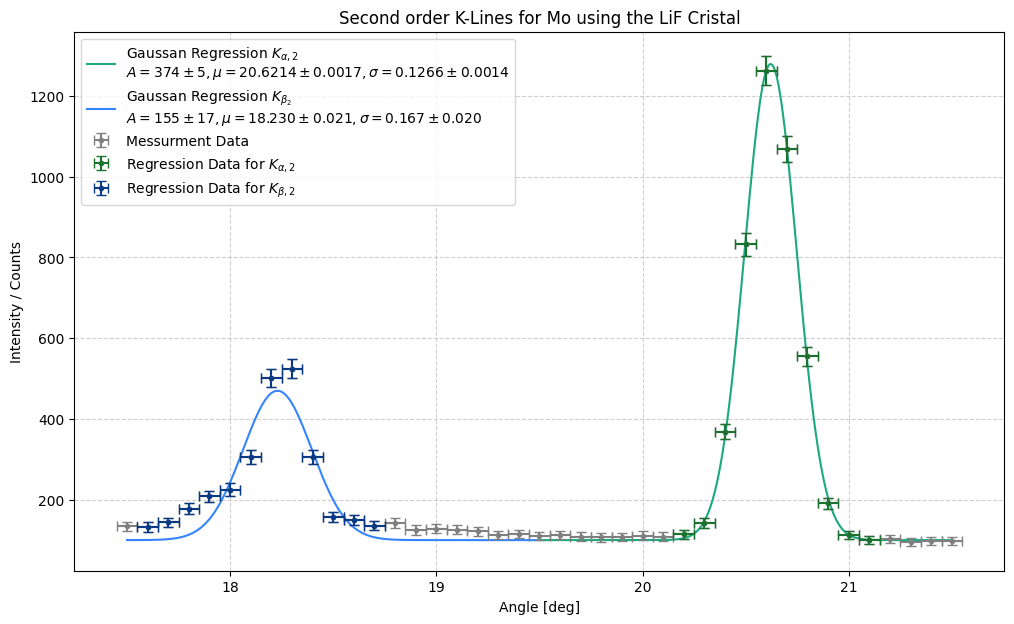

In [67]:
def gauss(x, A, mu, sig):
    return A / (sqrt(2 * pi) * sig) * exp(- (x - mu) ** 2 / (2 * sig ** 2)) + 100

# Finding the HWFM of the K alpha_2 line in second order
task = '2d'
plt.figure(figsize = (12,7))

# Regressionfor K alpha_2
a_start, a_end = 27, -4

p0_alpha_2 = [1000, 20.5, 0.4]
popt_alpha_2, pcov_alpha_2 = curve_fit(gauss, angle_2ord[a_start:a_end], counts_2ord[a_start:a_end], p0_alpha_2, sigma = err_counts_2ord[a_start:a_end])
degx_alpha_2 = np.arange(19.5, 21.5, 0.01)

perr_alpha_2 = np.sqrt(np.diag(pcov_alpha_2))

A_alpha_2 = popt_alpha_2[0]
err_A_alpha_2 = perr_alpha_2[0]

mu_alpha_2 = popt_alpha_2[1]
err_mu_alpha_2 = perr_alpha_2[1]

sig_alpha_2 = popt_alpha_2[2]
err_sig_alpha_2 = perr_alpha_2[2]

# To see the results clearly
print(f"Fitted parameters (Amplitude, Mean, Sigma): {popt_alpha_2}")
print(f"Errors (Standard Deviations): {perr_alpha_2}")

plt.plot(
    degx_alpha_2, 
    gauss(degx_alpha_2, *popt_alpha_2), 
    label = 'Gaussan Regression $K_{\\alpha,2}$' + f'\n$A={pap.round_sig_digs(err_A_alpha_2, A_alpha_2)[2]}, \\mu={pap.round_sig_digs(err_mu_alpha_2, mu_alpha_2)[2]}, \\sigma={pap.round_sig_digs(err_sig_alpha_2, sig_alpha_2)[2]}$',
    color = c.LIGHT_GREEN
    )


# Regressionfor K beta_2
b_start, b_end = 1, -28

p0_beta_2 = [400, 18.3, 0.4]
popt_beta_2, pcov_beta_2 = curve_fit(gauss, angle_2ord[b_start:b_end], counts_2ord[b_start:b_end], p0_beta_2, sigma = err_counts_2ord[b_start:b_end])
degx_beta_2 = np.arange(17.5, 19.5, 0.01)

perr_beta_2 = np.sqrt(np.diag(pcov_beta_2))

A_beta_2 = popt_beta_2[0]
err_A_beta_2 = perr_beta_2[0]

mu_beta_2 = popt_beta_2[1]
err_mu_beta_2 = perr_beta_2[1]

sig_beta_2 = popt_beta_2[2]
err_sig_beta_2 = perr_beta_2[2]

# To see the results clearly
print(f"Fitted parameters (Amplitude, Mean, Sigma): {popt_beta_2}")
print(f"Errors (Standard Deviations): {perr_beta_2}")

plt.plot(
    degx_beta_2, 
    gauss(degx_beta_2, *popt_beta_2), 
    label = 'Gaussan Regression $K_{\\beta_2}$' f'\n$A={pap.round_sig_digs(err_A_beta_2, A_beta_2)[2]}, \\mu={pap.round_sig_digs(err_mu_beta_2, mu_beta_2)[2]}, \\sigma={pap.round_sig_digs(err_sig_beta_2, sig_beta_2)[2]}$',
    color = c.LIGHT_BLUE
    )

# Messurment data
plt.errorbar(
    angle_2ord,
    counts_2ord,
    err_counts_2ord,
    err_angle_2ord,
    label='Messurment Data',
    marker = '.',
    ls = ' ',
    capsize=3.5,
    color = 'gray'
    )

# Messurment data used for regression alpha_2
plt.errorbar(
    angle_2ord[a_start:a_end],
    counts_2ord[a_start:a_end],
    err_counts_2ord[a_start:a_end],
    err_angle_2ord,
    label='Regression Data for $K_{\\alpha,2}$',
    marker = '.',
    ls = ' ',
    capsize=3.5,
    color= c.GREEN
    )

# Messurment data used for regression alpha_2
plt.errorbar(
    angle_2ord[b_start:b_end],
    counts_2ord[b_start:b_end],
    err_counts_2ord[b_start:b_end],
    err_angle_2ord,
    label='Regression Data for $K_{\\beta,2}$',
    marker = '.',
    ls = ' ',
    capsize=3.5,
    color= c.BLUE
    )

plt.title(f'Second order K-Lines for Mo using the LiF Cristal')
plt.legend(loc = 'upper left')
plt.xlabel('Angle [deg]')
plt.ylabel('Intensity / Counts')
plt.grid(alpha = 0.6)

plt.savefig(f'{plt_save_folder}second_order_LiF_FWHM{task}.pdf')
plt.show()

In [68]:
# Calculating the actual FWHM for all for peaks

# Formula
FWHM = 2 * sp.sqrt(2 * sp.ln(2)) * sym.sigma

sigs = np.array([sig_alpha, sig_beta, sig_alpha_2, sig_beta_2])
err_sigs = np.array([err_sig_alpha, err_sig_beta, err_sig_alpha_2, err_sig_beta_2])
values = np.column_stack([
    sigs, err_sigs
])

temp = pap.do_it(FWHM, [sym.sigma], values, print_formula=True)
vals_FWHM = temp[:,0] #/ pi * 180
errs_FWHM = temp[:,1] #/ pi * 180

element = ['alpha_1', 'beta_1', 'alpha_2', 'beta_2']
for i in range(4):
    print(f'FWHM {element[i]} = ({pap.round_sig_digs(errs_FWHM[i], vals_FWHM[i])[2]})°')


gegebene Funktion:


<IPython.core.display.Math object>

-----------------------
Formel des absoluten Fehlers:


<IPython.core.display.Math object>

-----------------------
Formel des relativen Fehlers:


<IPython.core.display.Math object>

-----------------------
FWHM alpha_1 = (0.272 \pm 0.014)°
FWHM beta_1 = (0.35 \pm 0.03)°
FWHM alpha_2 = (0.298 \pm 0.003)°
FWHM beta_2 = (0.39 \pm 0.05)°


In [69]:
# # Calculating the actual FWHM for all for peaks

# # Formula
# FWHM_p = sym.mu + (2 * sp.sqrt(2 * sp.ln(2)) * sym.sigma) #/2
# FWHM_m = sym.mu - (2 * sp.sqrt(2 * sp.ln(2)) * sym.sigma) #/2

# FWHM_c = FWHM_p - FWHM_m

# sigs = np.array([sig_alpha, sig_beta, sig_alpha_2, sig_beta_2])
# err_sigs = np.array([err_sig_alpha, err_sig_beta, err_sig_alpha_2, err_sig_beta_2])

# muhs = np.array([mu_alpha, mu_beta, mu_alpha_2, mu_beta_2])
# err_muhs = np.array([err_mu_alpha, err_mu_beta, err_mu_alpha_2, err_mu_beta_2])


# values = np.column_stack([
#     muhs, err_muhs,
#     sigs, err_sigs
# ])

# temp = pap.do_it(FWHM_c, [sym.mu, sym.sigma], values, print_formula=True)
# vals_FWHM = temp[:,0] #/ pi * 180
# errs_FWHM = temp[:,1] #/ pi * 180
# for i in range(4):
#     print(f'FWHM {i} = ({pap.round_sig_digs(errs_FWHM[i], vals_FWHM[i])[2]})°')

In [70]:
def wlange(deg, d, n):
    return 2 / n * d * np.sin(np.deg2rad(deg))

In [71]:
# Halfwidth as wavelength

# a_1, b_1, a_, b_2
element = ['alpha_1', 'beta_1', 'alpha_2', 'beta_2']

for i in range (2):
    n = i + i * 1
    print(f'FWHM {element[n]}: ({pap.round_sig_digs(wlange(errs_FWHM[0:2], d_LiF, 1)[i], wlange(vals_FWHM[0:2], d_LiF, 1)[i])[2]}) pm')
    print(f'FWHM {element[n + 1]}: ({pap.round_sig_digs(wlange(errs_FWHM[2:4], d_LiF, 2)[i], wlange(vals_FWHM[2:4], d_LiF, 2)[i])[2]}) pm')
    print('-' * 15)

FWHM alpha_1: (1.91 \pm 0.10) pm
FWHM beta_1: (1.048 \pm 0.012) pm
---------------
FWHM alpha_2: (2.49 \pm 0.24) pm
FWHM beta_2: (1.38 \pm 0.17) pm
---------------


<hr>

## Aufgabe 3

In [72]:
# Creating the Array for the voltages
steps = 15
U_B_T3 = np.zeros([steps])
err_U_B_T3 = 0.05 # kV
start_voltage = 20 # kV
for i in range(steps):
    U_B_T3[i] = start_voltage
    start_voltage = start_voltage + 1

# U_B * u.kV

In [73]:
# Cretaing the array for the counts for each foltage
counts_T3 = np.array([0.9, 1.05, 1.85, 23.15, 116.2, 321.6, 405.1, 573.1, 673.8, 769.2, 945.8, 1011.4, 1090.8, 1172.5, 1235.7])
# print(f'Same amount of voltages and counts: {len(U_B_T3) == len(counts_T3)}')

# Error form limited display
err_counts_T3 = np.zeros([steps])
for i in range(steps):
    if counts_T3[i] > 100:
        err_counts_T3[i] = 0.05
    else:
        err_counts_T3[i] = 0.005

err_n_T3 = sqrt(err_counts_T3**2 + sqrt(counts_T3)**2)

7.321202087089251


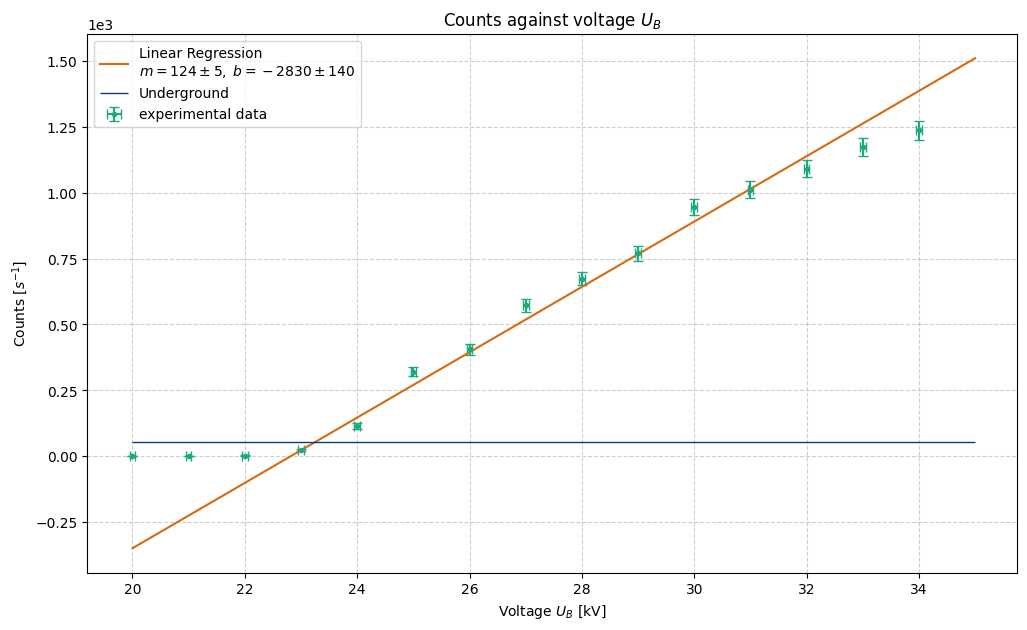

<Axes: title={'center': 'Counts against voltage $U_B$'}, xlabel='Voltage $U_B$ [kV]', ylabel='Counts [$s^{-1}$]'>

In [74]:
task = '3a'
plt.figure(figsize = (12,7))

plt.errorbar(
    U_B_T3,
    counts_T3,
    err_n_T3,
    err_U_B_T3,
    marker = '.',
    ls = ' ',
    label='experimental data',
    capsize= 3.5
)

# Regression
# Range of linear regression
start, end = 4, -1
popt_T4, pcov_T4 = curve_fit(linear, U_B_T3[start:end], counts_T3[start:end], sigma=err_n_T3[start:end])

slope_T4 = popt_T4[0]
ordinate_T4 = popt_T4[1]

# Extract uncertainties
perr = np.sqrt(np.diag(pcov_T4)) 

err_slope_T4 = perr[0]
err_ordinate_T4 = perr[1]

x = np.linspace(20, 35, 1000)
plt.plot(
    x,
    linear(x, *popt_T4),
    label = f'Linear Regression\n$m={pap.round_sig_digs(err_slope_T4, slope_T4)[2]}, \\; b={pap.round_sig_digs(err_ordinate_T4, ordinate_T4)[2]}$'
)

plt.hlines(
    [underground],
    20,
    35,
    lw = 1,
    colors= c.BLUE,
    label='Underground'
)

print(sqrt(underground))

pap.plot_me('Counts against voltage $U_B$', 'Voltage $U_B$ [kV]', 'Counts [$s^{-1}$]', f'{plt_save_folder}Against_U_B_{task}')

In [92]:
val = np.arange(22.3, 25, 0.001)
for i in range(0, 1000):
    if linear(val[i], *popt_T4) >= underground:
        U_E = val[i] #kV
        break
for i in range(0, 10000):
    if linear(val[i], *popt_T4) >= underground - err_underground:
        err_U_E = sqrt(np.abs(U_E - val[i])**2 + 0.05**2)
        break

print(f'Einsatzspannung U_E = ({pap.round_sig_digs(err_U_E, U_E)[2]}) kV')

Einsatzspannung U_E = (23.25 \pm 0.08) kV


In [76]:
# Finding Plack's constant (once again)
lam_sym = sp.symbols('\\lambda')

h_2 = lam_sym * sym.U * sym.e / sym.c

beta_here = 7.5
beta_lam =  wlange(beta_here, d_LiF, 1)

err_beta_here = 0.05
err_beta_lam =  wlange(err_beta_here, d_LiF, 1)

values = np.column_stack([
    beta_lam * 1e-12, err_beta_lam * 1e-12,
    U_E * 1e3, err_U_E * 1e3,
    const.e,
    const.c
])

temp = pap.do_it(h_2, [lam_sym, sym.U, sym.e, sym.c], values, [sym.e, sym.c], True)

val_h_2 = temp[:,0][0] * 1e34
err_h_2 = temp[:,1][0] * 1e34

print(f'The plancks constant is: h = ({pap.round_sig_digs(err_h_2, val_h_2)[2]}) *10^-34 J s ')

std_div_h2 = pap.std_abw(val_h_2, const.h * 1e34, err_h_2)
print(f'The standard diviation to the lit value is: {std_div_h2} sigma')

gegebene Funktion:


<IPython.core.display.Math object>

-----------------------
Formel des absoluten Fehlers:


<IPython.core.display.Math object>

-----------------------
Formel des relativen Fehlers:


<IPython.core.display.Math object>

-----------------------
The plancks constant is: h = (6.53 \pm 0.05) *10^-34 J s 
The standard diviation to the lit value is: 2.02 sigma


<hr>

## Aufgabe 4

In [77]:
# Import txt Data
angle_T4, counts_T4 = np.loadtxt('data/T4.txt', dtype=str, unpack=True)
angle_T4 = np.char.replace(angle_T4, ',', '.').astype(float)
err_angle_T4 = 0.05 # deg
counts_T4 = np.char.replace(counts_T4, ',', '.').astype(float)
err_counts_T4 = sqrt(counts_T4)

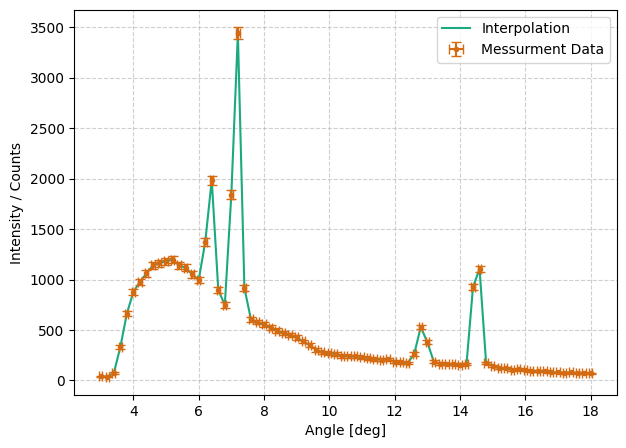

In [93]:
task = '4z'
plt.figure(figsize = (7,5))


# Default interpolation
plt.plot(
    angle_T4,
    counts_T4,
    label='Interpolation',
    )

# Messurment data
plt.errorbar(
    angle_T4,
    counts_T4,
    err_counts_T4,
    err_angle_T4,
    label='Messurment Data',
    marker = '.',
    ls = ' ',
    capsize=3.5,
    )


plt.legend(loc = 'upper right')
plt.xlabel('Angle [deg]')
plt.ylabel('Intensity / Counts')
plt.grid(alpha = 0.6)

plt.savefig(f'{plt_save_folder}NaCl_{task}.pdf')
plt.show()

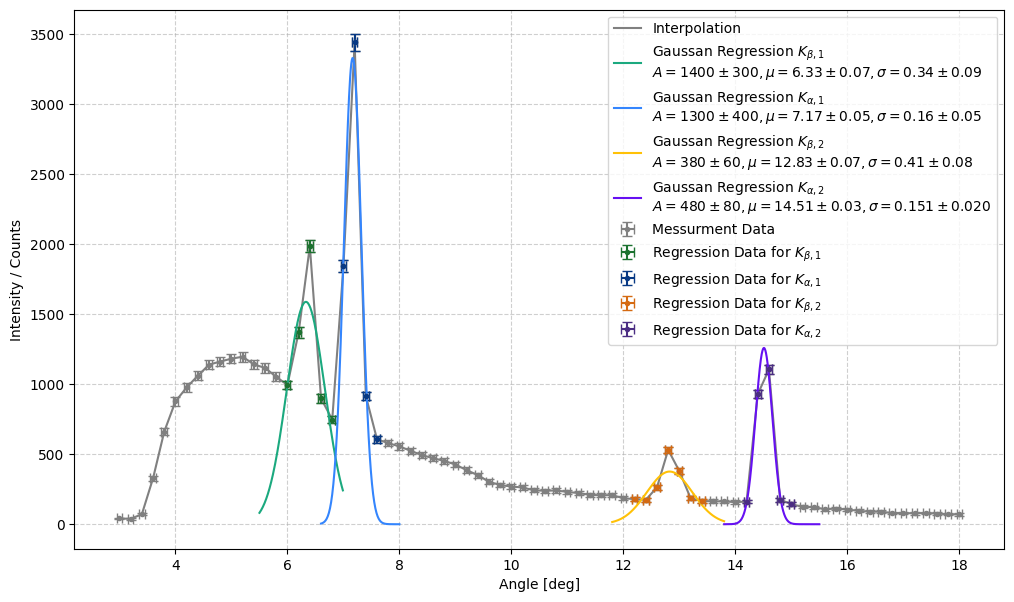

In [79]:
task = '4a'
plt.figure(figsize = (12,7))

def gauss(x, A, mu, sig):
    return A / (sqrt(2 * pi) * sig) * exp(- (x - mu) ** 2 / (2 * sig ** 2))

# Default interpolation
plt.plot(
    angle_T4,
    counts_T4,
    label='Interpolation',
    color = 'gray'
    )

# Messurment data
plt.errorbar(
    angle_T4,
    counts_T4,
    err_counts_T4,
    err_angle_T4,
    label='Messurment Data',
    marker = '.',
    ls = ' ',
    capsize=3.5,
    color = 'gray'
    )

# Regressionfor K beta
a_start, a_end = 15, 20

p0_beta_T4 = [1800, 6.4, 0.4]
popt_beta_T4, pcov_beta_T4 = curve_fit(gauss, angle_T4[a_start:a_end], counts_T4[a_start:a_end], p0_beta_T4, sigma = err_counts_T4[a_start:a_end])
degx_beta_T4 = np.arange(5.5, 7, 0.01)

perr_beta_T4 = np.sqrt(np.diag(pcov_beta_T4))

A_beta_T4 = popt_beta_T4[0]
err_A_beta_T4 = perr_beta_T4[0]

mu_beta_T4 = popt_beta_T4[1]
err_mu_beta_T4 = perr_beta_T4[1]

sig_beta_T4 = popt_beta_T4[2]
err_sig_beta_T4 = perr_beta_T4[2]

# Messurment data used for regression Alpha
plt.errorbar(
    angle_T4[a_start:a_end],
    counts_T4[a_start:a_end],
    err_counts_T4[a_start:a_end],
    err_angle_T4,
    label='Regression Data for $K_{\\beta,1}$',
    marker = '.',
    ls = ' ',
    capsize=3.5,
    color= c.GREEN
    )

plt.plot(
    degx_beta_T4, 
    gauss(degx_beta_T4, *popt_beta_T4), 
    label = 'Gaussan Regression $K_{\\beta,1}$' + f'\n$A={pap.round_sig_digs(err_A_beta_T4, A_beta_T4)[2]}, \\mu={pap.round_sig_digs(err_mu_beta_T4, mu_beta_T4)[2]}, \\sigma={pap.round_sig_digs(err_sig_beta_T4, sig_beta_T4)[2]}$',
    color = c.LIGHT_GREEN
    )

# Regressionfor K alpha
a_start, a_end = 20, 24

p0_alpha_T4 = [1800, 6.4, 0.4]
popt_alpha_T4, pcov_alpha_T4 = curve_fit(gauss, angle_T4[a_start:a_end], counts_T4[a_start:a_end], p0_alpha_T4, sigma = err_counts_T4[a_start:a_end])
degx_alpha_T4 = np.arange(6.6, 8, 0.01)

perr_alpha_T4 = np.sqrt(np.diag(pcov_alpha_T4))

A_alpha_T4 = popt_alpha_T4[0]
err_A_alpha_T4 = perr_alpha_T4[0]

mu_alpha_T4 = popt_alpha_T4[1]
err_mu_alpha_T4 = perr_alpha_T4[1]

sig_alpha_T4 = popt_alpha_T4[2]
err_sig_alpha_T4 = perr_alpha_T4[2]

# Messurment data used for regression Alpha
plt.errorbar(
    angle_T4[a_start:a_end],
    counts_T4[a_start:a_end],
    err_counts_T4[a_start:a_end],
    err_angle_T4,
    label='Regression Data for $K_{\\alpha,1}$',
    marker = '.',
    ls = ' ',
    capsize=3.5,
    color= c.BLUE
    )

plt.plot(
    degx_alpha_T4, 
    gauss(degx_alpha_T4, *popt_alpha_T4), 
    label = 'Gaussan Regression $K_{\\alpha,1}$' + f'\n$A={pap.round_sig_digs(err_A_alpha_T4, A_alpha_T4)[2]}, \\mu={pap.round_sig_digs(err_mu_alpha_T4, mu_alpha_T4)[2]}, \\sigma={pap.round_sig_digs(err_sig_alpha_T4, sig_alpha_T4)[2]}$',
    color = c.LIGHT_BLUE
    )


# Regressionfor K beta 
a_start, a_end = 46, 53

p0_beta_T4_2 = [150, 12.8, 0.08]
popt_beta_T4_2, pcov_beta_T4_2 = curve_fit(gauss, angle_T4[a_start:a_end], counts_T4[a_start:a_end], p0_beta_T4_2, sigma = err_counts_T4[a_start:a_end])
degx_beta_T4_2 = np.arange(11.8, 13.8, 0.001)

perr_beta_T4_2 = np.sqrt(np.diag(pcov_beta_T4_2))

A_beta_T4_2 = popt_beta_T4_2[0]
err_A_beta_T4_2 = perr_beta_T4_2[0]

mu_beta_T4_2 = popt_beta_T4_2[1]
err_mu_beta_T4_2 = perr_beta_T4_2[1]

sig_beta_T4_2 = popt_beta_T4_2[2]
err_sig_beta_T4_2 = perr_beta_T4_2[2]

# Messurment data used for regression Alpha
plt.errorbar(
    angle_T4[a_start:a_end],
    counts_T4[a_start:a_end],
    err_counts_T4[a_start:a_end],
    err_angle_T4,
    label='Regression Data for $K_{\\beta,2}$',
    marker = '.',
    ls = ' ',
    capsize=3.5,
    color= c.ORANGE
    )

plt.plot(
    degx_beta_T4_2, 
    gauss(degx_beta_T4_2, *popt_beta_T4_2), 
    label = 'Gaussan Regression $K_{\\beta,2}$' + f'\n$A={pap.round_sig_digs(err_A_beta_T4_2, A_beta_T4_2)[2]}, \\mu={pap.round_sig_digs(err_mu_beta_T4_2, mu_beta_T4_2)[2]}, \\sigma={pap.round_sig_digs(err_sig_beta_T4_2, sig_beta_T4_2)[2]}$',
    color = c.YELLOW
    )

# Regressionfor K alpha 2
a_start, a_end = 56, 61

p0_alpha_T4_2 = [150, 14.5, 0.08]
popt_alpha_T4_2, pcov_alpha_T4_2 = curve_fit(gauss, angle_T4[a_start:a_end], counts_T4[a_start:a_end], p0_alpha_T4_2, sigma = err_counts_T4[a_start:a_end])
degx_alpha_T4_2 = np.arange(13.8, 15.5, 0.001)

perr_alpha_T4_2 = np.sqrt(np.diag(pcov_alpha_T4_2))

A_alpha_T4_2 = popt_alpha_T4_2[0]
err_A_alpha_T4_2 = perr_alpha_T4_2[0]

mu_alpha_T4_2 = popt_alpha_T4_2[1]
err_mu_alpha_T4_2 = perr_alpha_T4_2[1]

sig_alpha_T4_2 = popt_alpha_T4_2[2]
err_sig_alpha_T4_2 = perr_alpha_T4_2[2]

# Messurment data used for regression Alpha
plt.errorbar(
    angle_T4[a_start:a_end],
    counts_T4[a_start:a_end],
    err_counts_T4[a_start:a_end],
    err_angle_T4,
    label='Regression Data for $K_{\\alpha,2}$',
    marker = '.',
    ls = ' ',
    capsize=3.5,
    color= c.DARK_PURPLE
    )

plt.plot(
    degx_alpha_T4_2, 
    gauss(degx_alpha_T4_2, *popt_alpha_T4_2), 
    label = 'Gaussan Regression $K_{\\alpha,2}$' + f'\n$A={pap.round_sig_digs(err_A_alpha_T4_2, A_alpha_T4_2)[2]}, \\mu={pap.round_sig_digs(err_mu_alpha_T4_2, mu_alpha_T4_2)[2]}, \\sigma={pap.round_sig_digs(err_sig_alpha_T4_2, sig_alpha_T4_2)[2]}$',
    color = c.PURPLE
    )


plt.legend(loc = 'upper right')
plt.xlabel('Angle [deg]')
plt.ylabel('Intensity / Counts')
plt.grid(alpha = 0.6)

plt.savefig(f'{plt_save_folder}NaCl_{task}.pdf')
plt.show()

In [80]:
# extracting the according angles

lol = [1,1,2,2]
labs = ['alpha_1', 'beta_1', 'alpha_2', 'beta_2']
angles = np.array([mu_alpha_T4, mu_beta_T4, mu_alpha_T4_2, mu_beta_T4_2])
err_angles = np.array([sig_alpha_T4, sig_beta_T4, sig_alpha_T4_2, sig_beta_T4_2])

for i in range(4):
    print(f'{labs[i]}: ({pap.round_sig_digs(err_angles[i], angles[i])[2]})°')
    print(f'Expected wave length by lit value: {labs[i]}: ({pap.round_sig_digs(wlange(err_angles[i],564/2, lol[i]), wlange(angles[i],564/2, lol[i]))[2]})pm')
    print('-' * 15)


alpha_1: (7.17 \pm 0.16)°
Expected wave length by lit value: alpha_1: (70.3 \pm 1.5)pm
---------------
beta_1: (6.3 \pm 0.3)°
Expected wave length by lit value: beta_1: (62 \pm 3)pm
---------------
alpha_2: (14.51 \pm 0.15)°
Expected wave length by lit value: alpha_2: (70.7 \pm 0.7)pm
---------------
beta_2: (12.8 \pm 0.4)°
Expected wave length by lit value: beta_2: (62.6 \pm 2.0)pm
---------------


In [81]:
g_const = lam_sym / sp.sin(sym.theta) * sym.n

values = np.column_stack([
    [Mo_wavelength_alpha] * 4, [err_Mo_wavelength_alpha] * 4,
    angles * np.pi / 180, err_angles * np.pi / 180,
    [1,1,2,2]
])

temp_g = pap.do_it(g_const, [lam_sym, sym.theta, sym.n], values, [sym.n], True)

g_const = np.mean(temp_g[:,0])
err_g_const = np.mean(sqrt(temp_g[:,1]**2))
print(f'The estimated constant is: ({pap.round_sig_digs(err_g_const, g_const)[2]}) pm')

gegebene Funktion:


<IPython.core.display.Math object>

-----------------------
Formel des absoluten Fehlers:


<IPython.core.display.Math object>

-----------------------
Formel des relativen Fehlers:


<IPython.core.display.Math object>

-----------------------
The estimated constant is: (606 \pm 19) pm


In [82]:
lit_g_const_NaCl = 564.00 # pm

sd_g_each = pap.std_abw(lit_g_const_NaCl, temp_g[:,0], temp_g[:,1])
print(f'Standard diviation for each single g const:\n{sd_g_each}')

sd_g = pap.std_abw(lit_g_const_NaCl, g_const, err_g_const)
print(f'Standard diviation for the average:\n{sd_g}')


Standard diviation for each single g const:
[0.47 2.33 0.54 3.78]
Standard diviation for the average:
2.25


In [83]:
# Build the dataframe
table_data = []
for i in range(4):
    row = {
        r'label': labs[i],
        r'\text{angle [deg]}': pap.round_sig_digs(err_angles[i], angles[i])[2],
        r'\text{Expected} \lambda_\text{Mo} [\mathrm{pm}]': pap.round_sig_digs(wlange(err_angles[i],564/2, lol[i]), wlange(angles[i],564/2, lol[i]))[2],
        r'\text{Lattice constant NaCl} [\mathrm{pm}]': pap.round_sig_digs(temp_g[:,1][i], temp_g[:,0][i])[2],
        r'\sigma': f'{sd_g_each[i]:.2f}'
    }
    table_data.append(row)

df_latex = pd.DataFrame(table_data)

# Add summary row for mean lattice constant
summary_row = pd.DataFrame([{
    r'label': 'Mean',
    r'\text{angle [deg]}': '',
    r'\text{Expected} \lambda_\text{Mo} [\mathrm{pm}]': '',
    r'\text{Lattice constant NaCl} [\mathrm{pm}]' : pap.round_sig_digs(err_g_const, g_const)[2],
    r'\sigma': sd_g
}])

df_final = pd.concat([df_latex.reset_index(drop=True), summary_row], ignore_index=True)

# Generate LaTeX output
print(df_final.to_latex(index=True, caption='X-ray Diffraction Analysis Results', label='tab:xray_analysis'))

\begin{table}
\caption{X-ray Diffraction Analysis Results}
\label{tab:xray_analysis}
\begin{tabular}{llllll}
\toprule
 & label & \text{angle [deg]} & \text{Expected} \lambda_\text{Mo} [\mathrm{pm}] & \text{Lattice constant NaCl} [\mathrm{pm}] & \sigma \\
\midrule
0 & alpha_1 & 7.17 \pm 0.16 & 70.3 \pm 1.5 & 570 \pm 13 & 0.47 \\
1 & beta_1 & 6.3 \pm 0.3 & 62 \pm 3 & 640 \pm 30 & 2.33 \\
2 & alpha_2 & 14.51 \pm 0.15 & 70.7 \pm 0.7 & 567 \pm 7 & 0.54 \\
3 & beta_2 & 12.8 \pm 0.4 & 62.6 \pm 2.0 & 641 \pm 20 & 3.78 \\
4 & Mean &  &  & 606 \pm 19 & 2.250000 \\
\bottomrule
\end{tabular}
\end{table}



In [91]:
# Calculation N_A

N_A_func = 4 * sym.M / sym.rho / (sym.g**3)

values = np.array([
    g_const * 1e-10, err_g_const * 1e-10,
    58.44,
    2.164
])

temp = pap.do_it(N_A_func, [sym.g, sym.M, sym.rho], values, [sym.M, sym.rho], False)
val_NA = temp[0][0] *1e-23
err_NA = temp[0][1] *1e-23

print(f'The Avogadro Number is: N_A = ({pap.round_sig_digs(err_NA ,val_NA)[2]}) * 10^23 1/mol')

# for the better results of the alpha K lines:
values = np.array([
    temp_g[:,0][0] * 1e-10, temp_g[:,1][0] * 1e-10,
    58.44,
    2.164
])

temp = pap.do_it(N_A_func, [sym.g, sym.M, sym.rho], values, [sym.M, sym.rho], False)
val_NA_alpha_1 = temp[0][0] *1e-23
err_NA_alpha_1 = temp[0][1] *1e-23

print(f'The Avogadro Number for only alpha_1 is: N_A = ({pap.round_sig_digs(err_NA_alpha_1 ,val_NA_alpha_1)[2]}) * 10^23 1/mol')

print(const.N_A)

print(f'Standard Deviation for the mean: {pap.std_abw(const.N_A * 1e-23, val_NA, err_NA)}')
print(f'Standard Deviation for K-alpha: {pap.std_abw(const.N_A * 1e-23, val_NA_alpha_1, err_NA_alpha_1)}')


The Avogadro Number is: N_A = (4.9 \pm 0.4) * 10^23 1/mol
The Avogadro Number for only alpha_1 is: N_A = (5.8 \pm 0.4) * 10^23 1/mol
6.02214076e+23
Standard Deviation for the mean: 2.6
Standard Deviation for K-alpha: 0.48
